# 04 â€” XGBoost Tuning with MLflow Tracking

Replace the logistic regression baseline with XGBoost.
Tune hyperparameters with Optuna, log every trial to MLflow,
then explain the best model with SHAP.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

import xgboost as xgb
import optuna
import mlflow
import mlflow.xgboost
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score,
)

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
TEST_SIZE    = 0.2
N_TRIALS     = 30
CV_FOLDS     = 3
MODELS_PATH  = Path('../outputs/models')
FIGURES_PATH = Path('../outputs/figures')
MODELS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "C:\ProgramData\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\ProgramData\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\New User\AppData\Roaming\Pyth

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



## 1. Load & prep

In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')
df['log_amount']  = np.log1p(df['Amount'])
df['hour_of_day'] = (df['Time'] // 3600) % 24
df = df.drop(columns=['Time', 'Amount'])

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# XGBoost handles scale internally but we keep the ratio for scale_pos_weight
neg, pos        = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.1f}  ({neg:,} legit / {pos} fraud in train)")

scale_pos_weight = 577.3  (227,451 legit / 394 fraud in train)


## 2. XGBoost baseline (no tuning)

Establish the out-of-the-box score before Optuna touches anything.

In [3]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=RANDOM_STATE,
    use_label_encoder=False,
)
base_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

base_prob  = base_xgb.predict_proba(X_test)[:, 1]
base_prauc = average_precision_score(y_test, base_prob)
print(f"Baseline XGBoost PR-AUC : {base_prauc:.4f}")

Baseline XGBoost PR-AUC : 0.8823


## 3. Hyperparameter tuning with Optuna + MLflow

Each Optuna trial is logged as a child run under the parent MLflow experiment.
CV is stratified so every fold sees representative fraud counts.

In [4]:
mlflow.set_experiment('fraud-xgboost-tuning')

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 20),
        'gamma'             : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'scale_pos_weight'  : scale_pos_weight,
        'eval_metric'       : 'aucpr',
        'random_state'      : RANDOM_STATE,
        'use_label_encoder' : False,
    }

    fold_scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        Xf_tr, Xf_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        yf_tr, yf_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        m = xgb.XGBClassifier(**params)
        m.fit(Xf_tr, yf_tr, verbose=False)
        fold_scores.append(average_precision_score(yf_val, m.predict_proba(Xf_val)[:, 1]))

    mean_prauc = float(np.mean(fold_scores))

    with mlflow.start_run(nested=True):
        mlflow.log_params(params)
        mlflow.log_metric('cv_pr_auc', mean_prauc)

    return mean_prauc


with mlflow.start_run(run_name='optuna-parent'):
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_metric('best_cv_pr_auc', study.best_value)
    mlflow.log_params(study.best_params)

print(f"\nBest CV PR-AUC : {study.best_value:.4f}")
print(f"Best params    : {study.best_params}")

  0%|          | 0/30 [00:00<?, ?it/s]


Best CV PR-AUC : 0.8515
Best params    : {'n_estimators': 445, 'max_depth': 6, 'learning_rate': 0.05166824416781478, 'subsample': 0.7277951215378928, 'colsample_bytree': 0.8006662076091197, 'min_child_weight': 6, 'gamma': 0.5657330192103727, 'reg_alpha': 0.20955559557475822, 'reg_lambda': 0.017818682160357237}


## 4. Retrain best params on full training set

In [5]:
best_params = study.best_params | {
    'scale_pos_weight' : scale_pos_weight,
    'eval_metric'      : 'aucpr',
    'random_state'     : RANDOM_STATE,
}

best_model = xgb.XGBClassifier(**best_params)
best_model.fit(X_train, y_train, verbose=False)

y_prob  = best_model.predict_proba(X_test)[:, 1]
y_pred  = (y_prob >= 0.5).astype(int)
prauc   = average_precision_score(y_test, y_prob)
rocauc  = roc_auc_score(y_test, y_prob)
prec    = precision_score(y_test, y_pred)
rec     = recall_score(y_test, y_pred)
f1      = f1_score(y_test, y_pred)

print(f"Tuned XGBoost PR-AUC  : {prauc:.4f}  (baseline was {base_prauc:.4f})")
print(f"Tuned XGBoost ROC-AUC : {rocauc:.4f}")
print(f"Precision             : {prec:.4f}")
print(f"Recall                : {rec:.4f}")
print(f"F1                    : {f1:.4f}")

Tuned XGBoost PR-AUC  : 0.8792  (baseline was 0.8823)
Tuned XGBoost ROC-AUC : 0.9849
Precision             : 0.8454
Recall                : 0.8367
F1                    : 0.8410


## 5. Confusion matrix

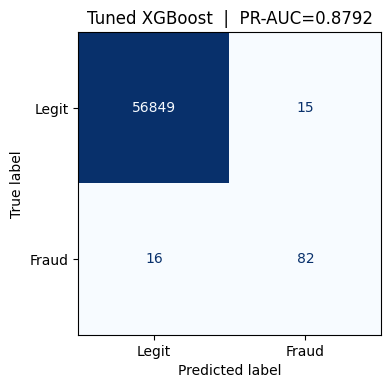

Fraud caught (TP) : 82
Fraud missed (FN) : 16
False alarms (FP) : 15
Correct legit (TN): 56,849


In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)
ax.set_title(f'Tuned XGBoost  |  PR-AUC={prauc:.4f}')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Fraud caught (TP) : {tp}")
print(f"Fraud missed (FN) : {fn}")
print(f"False alarms (FP) : {fp}")
print(f"Correct legit (TN): {tn:,}")

## 6. SHAP explainability (overview)

Quick global feature importance using SHAP.
Notebook 05 covers SHAP in full depth (beeswarm, waterfall, dependence plots).

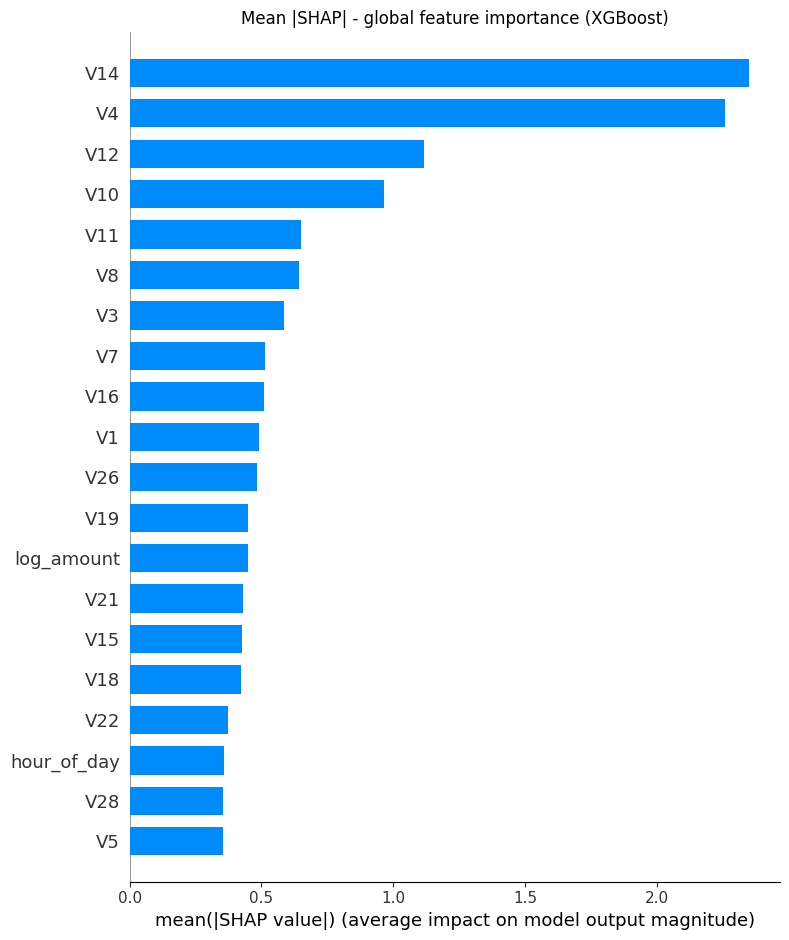

Top 5 fraud signals (SHAP):
  V14       mean |SHAP|=2.3502
  V4        mean |SHAP|=2.2606
  V12       mean |SHAP|=1.1159
  V10       mean |SHAP|=0.9639
  V11       mean |SHAP|=0.6490


In [7]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Mean |SHAP| - global feature importance (XGBoost)')
plt.tight_layout()
plt.savefig(FIGURES_PATH / '04_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

mean_shap_04 = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
print("Top 5 fraud signals (SHAP):")
for feat, score in mean_shap_04.head(5).items():
    print(f"  {feat:8s}  mean |SHAP|={score:.4f}")

## 7. Save model and log final run to MLflow

In [8]:
joblib.dump(best_model, MODELS_PATH / 'best_xgb.pkl')
print("Saved: outputs/models/best_xgb.pkl")

with mlflow.start_run(run_name='final-xgboost'):
    mlflow.log_params(best_params)
    mlflow.log_metrics({
        'test_pr_auc' : prauc,
        'test_roc_auc': rocauc,
        'precision'   : prec,
        'recall'      : rec,
        'f1'          : f1,
    })
    mlflow.xgboost.log_model(best_model, name='model')

print("\n" + "=" * 55)
print("XGBOOST TUNING SUMMARY")
print("=" * 55)
print(f"  Baseline XGBoost PR-AUC  : {base_prauc:.4f}")
print(f"  Tuned XGBoost PR-AUC     : {prauc:.4f}")
print(f"  ROC-AUC                  : {rocauc:.4f}")
print(f"  Precision                : {prec:.4f}")
print(f"  Recall                   : {rec:.4f}")
print(f"  F1                       : {f1:.4f}")
print(f"  Fraud caught             : {tp} / {y_test.sum()} ({tp/y_test.sum()*100:.1f}%)")
print(f"  Fraud missed             : {fn}")
print(f"  Best params              : {study.best_params}")
print(f"\nNext: notebook 05 - SHAP explainability in full depth.")
print("=" * 55)

Saved: outputs/models/best_xgb.pkl

XGBOOST TUNING SUMMARY
  Baseline XGBoost PR-AUC  : 0.8823
  Tuned XGBoost PR-AUC     : 0.8792
  ROC-AUC                  : 0.9849
  Precision                : 0.8454
  Recall                   : 0.8367
  F1                       : 0.8410
  Fraud caught             : 82 / 98 (83.7%)
  Fraud missed             : 16
  Best params              : {'n_estimators': 445, 'max_depth': 6, 'learning_rate': 0.05166824416781478, 'subsample': 0.7277951215378928, 'colsample_bytree': 0.8006662076091197, 'min_child_weight': 6, 'gamma': 0.5657330192103727, 'reg_alpha': 0.20955559557475822, 'reg_lambda': 0.017818682160357237}

Next: notebook 05 - SHAP explainability in full depth.
